In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
data_path = 'processed/reviews_merged.csv'
print("reviews_merged yükleniyor...")
df = pd.read_csv(data_path)
print(f"Toplam satır: {len(df):,} | Benzersiz film (imdb_id): {df['imdb_id'].nunique():,}")
print("Sütunlar:", list(df.columns))
df.head()

reviews_merged yükleniyor...
Toplam satır: 382,977 | Benzersiz film (imdb_id): 229
Sütunlar: ['imdb_id', 'source', 'language', 'review_text', 'cleaned_text']


,imdb_id,source,language,review_text,cleaned_text
0,tt0111161,eksisozluk,tr,pek mantik hatasi yoktur bence bu filmde: 1) y...,mantik hatasi yildirim iceriyi aydinlat güclü ...
1,tt0111161,eksisozluk,tr,"korku, gerilim üstadı stephen king 'in the gre...",korku gerilim üstat stephen king in the green ...
2,tt0111161,eksisozluk,tr,"hapishaneden kaçış temalı izlenimi verse de, a...",hapishane kaç tema izlenim ver arka plan neo n...
3,tt0111161,eksisozluk,tr,hapishanede geçen neredeyse her film gibi liva...,hapishane geçen neredeyse livata fiil uç kıyı ...
4,tt0111161,sinemalar,tr,"Yerini hak eden, sinema tarihinin efsane filmi...",yer hak et tarih efsane


In [ ]:
print("Eksik Veri Sayıları:")
print(df.isnull().sum())

df = df.dropna(subset=['cleaned_text'])
print(f"\nTemizlik sonrası satır sayısı: {len(df):,}")

Eksik Veri Sayıları:
imdb_id         0
source          0
language        0
review_text     0
cleaned_text    0
dtype: int64

Temizlik sonrası satır sayısı: 382,977


language
en    191562
tr    191415
Name: count, dtype: int64


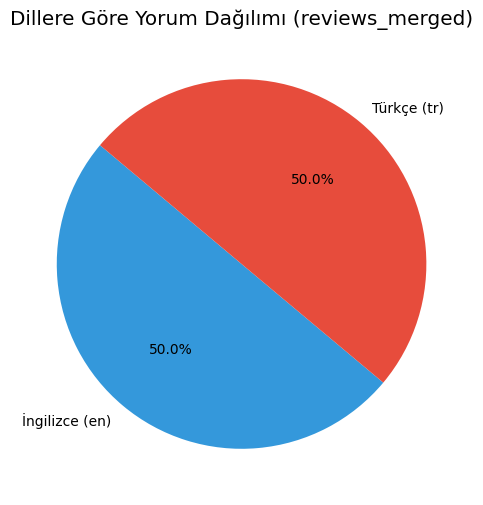

In [4]:
lang_counts = df['language'].value_counts()
print(lang_counts)

label_map = {'en': 'İngilizce (en)', 'tr': 'Türkçe (tr)'}
color_map = {'en': '#3498db', 'tr': '#e74c3c'}
labels = [label_map.get(i, str(i)) for i in lang_counts.index]
colors = [color_map.get(i, '#95a5a6') for i in lang_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(lang_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Dillere Göre Yorum Dağılımı (reviews_merged)")
plt.show()

source
letterboxd    99251
imdb          92311
sinemalar     89476
eksisozluk    82119
beyazperde    19820
Name: count, dtype: int64


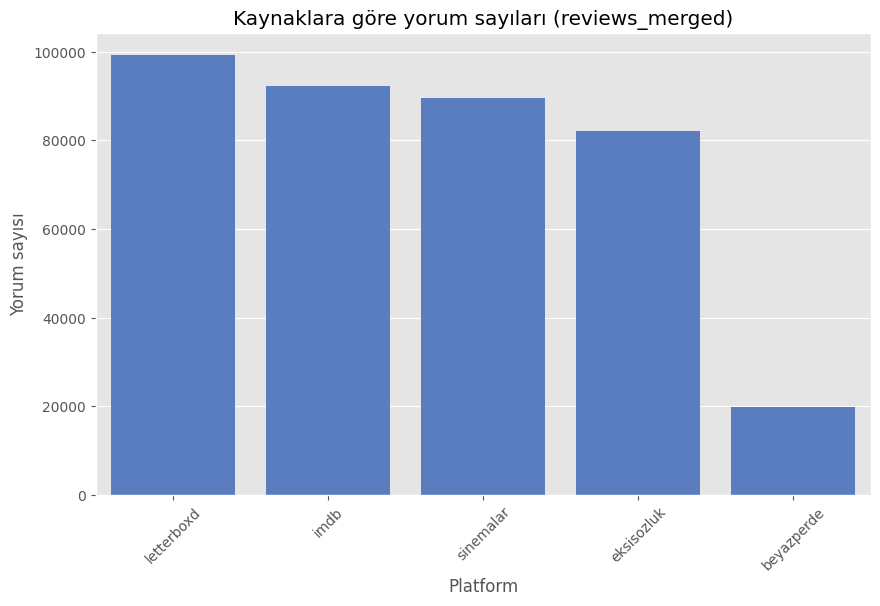

In [5]:
source_counts = df['source'].value_counts()
print(source_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=source_counts.index, y=source_counts.values)
plt.title('Kaynaklara göre yorum sayıları (reviews_merged)')
plt.ylabel('Yorum sayısı')
plt.xlabel('Platform')
plt.xticks(rotation=45)
plt.show()

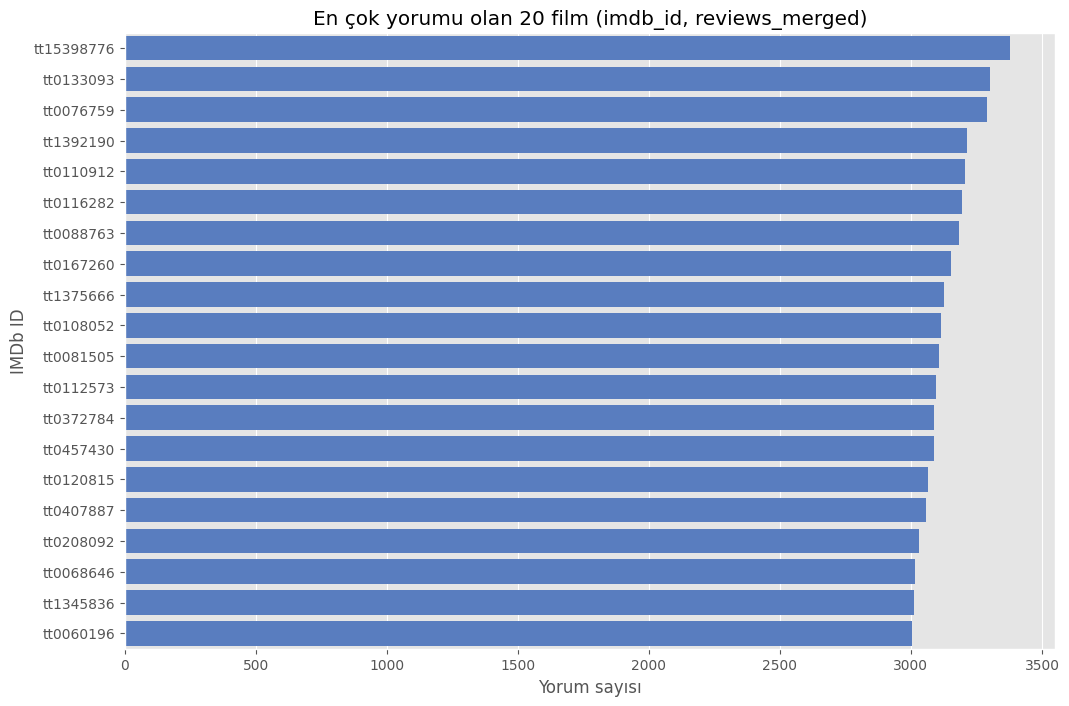

In [6]:
movie_counts = df['imdb_id'].value_counts().head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=movie_counts.values, y=movie_counts.index, orient='h')
plt.title('En çok yorumu olan 20 film (imdb_id, reviews_merged)')
plt.xlabel('Yorum sayısı')
plt.ylabel('IMDb ID')
plt.show()

Kelime sayısı temel istatistikleri:
             count       mean         std  min   25%   50%   75%     max
language                                                                
en        191562.0  78.325707  104.121830  5.0  18.0  48.0  96.0  4416.0
tr        191415.0  38.865726   81.948167  5.0  10.0  19.0  38.0  6671.0


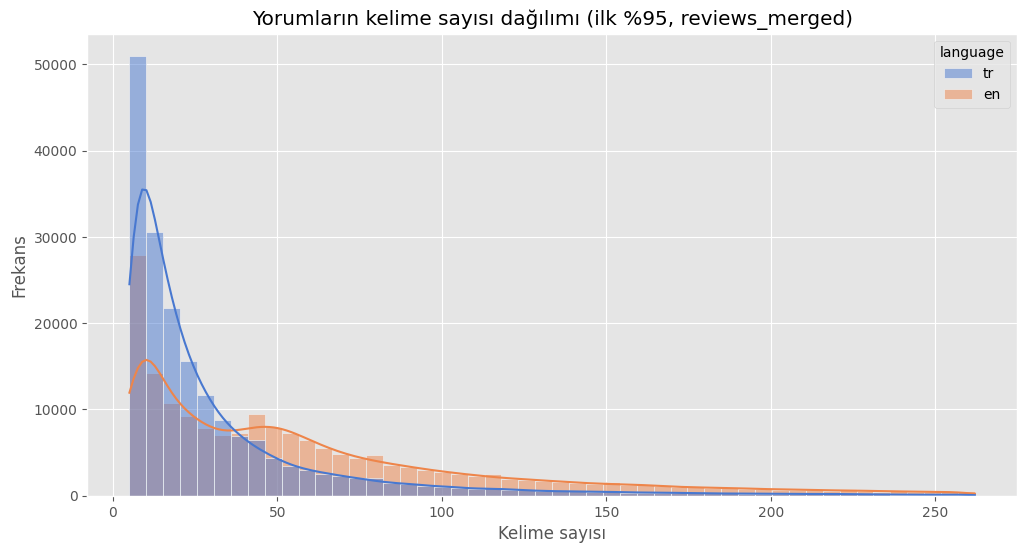

In [ ]:
df['word_count'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

print('Kelime sayısı temel istatistikleri:')
print(df.groupby('language')['word_count'].describe())

max_words_tr = df[df['language'] == 'tr']['word_count'].quantile(0.95)
max_words_en = df[df['language'] == 'en']['word_count'].quantile(0.95)
max_words = max(max_words_tr, max_words_en)

plt.figure(figsize=(12, 6))
sns.histplot(data=df[df['word_count'] <= max_words], x='word_count', hue='language', bins=50, kde=True)
plt.title('Yorumların kelime sayısı dağılımı (ilk %95, reviews_merged)')
plt.xlabel('Kelime sayısı')
plt.ylabel('Frekans')
plt.show()

En Sık Kullanılan Türkçe Kelimeler (Hesaplanıyor...)
En Sık Kullanılan İngilizce Kelimeler (Hesaplanıyor...)


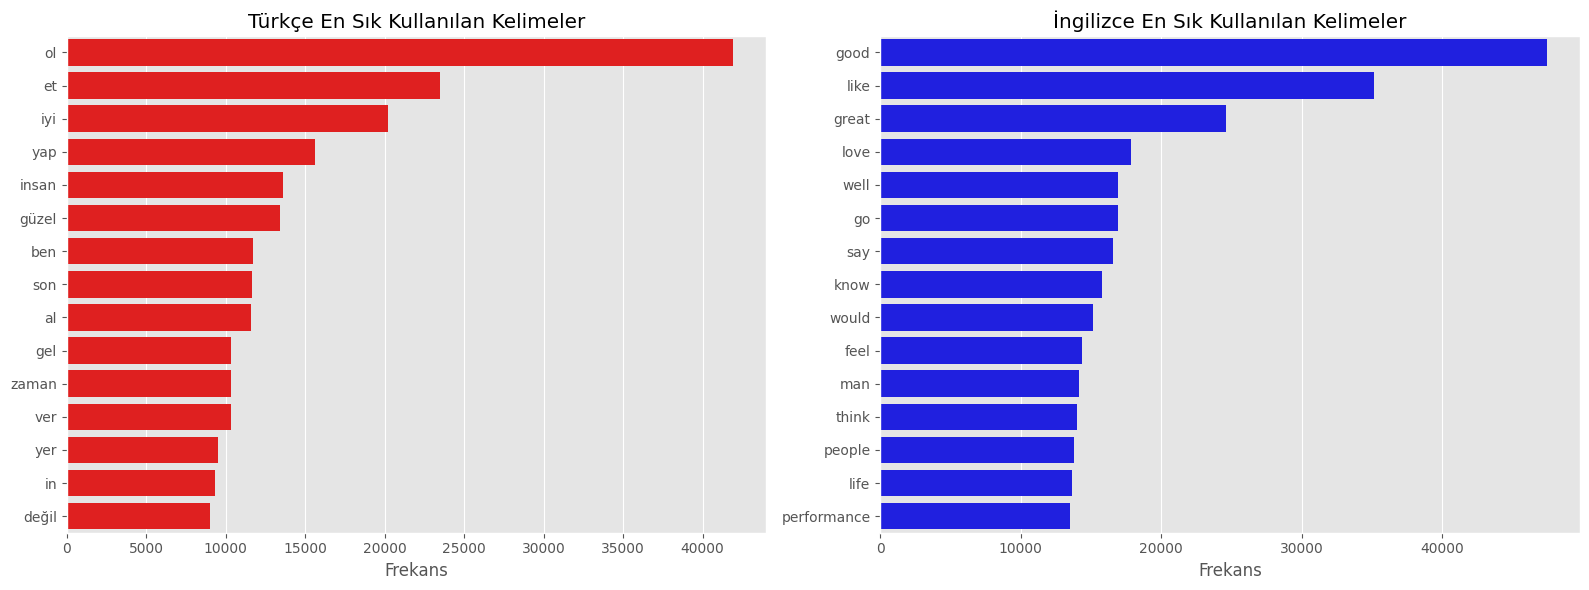

In [ ]:
from collections import Counter

def get_top_n_words(corpus, n=15):
    words = ' '.join(corpus).split()
    counter = Counter(words)
    return counter.most_common(n)

print("En Sık Kullanılan Türkçe Kelimeler (Hesaplanıyor...)")
tr_sample = df[df['language'] == 'tr']['cleaned_text'].sample(n=min(50000, len(df[df['language'] == 'tr'])), random_state=42)
top_tr = get_top_n_words(tr_sample.astype(str))

print("En Sık Kullanılan İngilizce Kelimeler (Hesaplanıyor...)")
en_sample = df[df['language'] == 'en']['cleaned_text'].sample(n=min(50000, len(df[df['language'] == 'en'])), random_state=42)
top_en = get_top_n_words(en_sample.astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=[val[1] for val in top_tr], y=[val[0] for val in top_tr], ax=axes[0], color='red')
axes[0].set_title('Türkçe En Sık Kullanılan Kelimeler')
axes[0].set_xlabel('Frekans')

sns.barplot(x=[val[1] for val in top_en], y=[val[0] for val in top_en], ax=axes[1], color='blue')
axes[1].set_title('İngilizce En Sık Kullanılan Kelimeler')
axes[1].set_xlabel('Frekans')

plt.tight_layout()
plt.show()

In [9]:
print(f"Korpus: {data_path}")
print(f"Satır: {len(df):,} | Film: {df['imdb_id'].nunique():,}")
print("\nDil:")
print(df['language'].value_counts())
tr_n, en_n = (df['language'] == 'tr').sum(), (df['language'] == 'en').sum()
print(f"TR/EN (satır oranı): {tr_n / en_n:.4f}")

print("\nKaynak × dil:")
print(pd.crosstab(df['source'], df['language'], margins=True))

ct_m = df.groupby(['imdb_id', 'language']).size().unstack(fill_value=0)
for c in ['tr', 'en']:
    if c not in ct_m.columns:
        ct_m[c] = 0
ct_m = ct_m.rename(columns={'tr': 'n_tr', 'en': 'n_en'})
ct_m['max_dil'] = ct_m[['n_tr', 'n_en']].max(axis=1)
ct_m['rel_fark'] = (ct_m['n_tr'] - ct_m['n_en']).abs() / ct_m['max_dil'].replace(0, float('nan'))
ct_m['esit'] = ct_m['n_tr'] == ct_m['n_en']

print("\nFilm başına denge:")
print(f"  TR==EN olan film sayısı: {ct_m['esit'].sum()} / {len(ct_m)}")
print(f"  min n_tr={ct_m['n_tr'].min()}, min n_en={ct_m['n_en'].min()}")
print(f"  max göreli |tr-en|/max: {ct_m['rel_fark'].max():.6f}")
print(f"  %5 kuralını ihlal eden film var mı: {(ct_m['rel_fark'] > 0.05 + 1e-9).any()}")

try:
    meta = pd.read_csv('raw/imdb_top250.csv')
    title_col = 'title' if 'title' in meta.columns else [c for c in meta.columns if 'title' in c.lower()][0]
    id_col = 'imdb_id' if 'imdb_id' in meta.columns else 'tconst'
    tmap = meta.set_index(id_col)[title_col].to_dict()
    ct_m['title'] = ct_m.index.map(lambda x: tmap.get(x, ''))
    print("\nGöreli farka göre (yüksekten, ilk 15): n_tr, n_en, rel_fark, başlık")
    show = ct_m.sort_values('rel_fark', ascending=False)[['n_tr', 'n_en', 'rel_fark', 'title']].head(15)
    print(show.to_string())
except Exception as e:
    print('Başlık okunamadı:', e)

Korpus: processed/reviews_merged.csv
Satır: 382,977 | Film: 229

Dil:
language
en    191562
tr    191415
Name: count, dtype: int64
TR/EN (satır oranı): 0.9992

Kaynak × dil:
language        en      tr     All
source                            
beyazperde       0   19820   19820
eksisozluk       0   82119   82119
imdb         92311       0   92311
letterboxd   99251       0   99251
sinemalar        0   89476   89476
All         191562  191415  382977

Film başına denge:
  TR==EN olan film sayısı: 225 / 229
  min n_tr=100, min n_en=100
  max göreli |tr-en|/max: 0.040248
  %5 kuralını ihlal eden film var mı: False

Göreli farka göre (yüksekten, ilk 15): n_tr, n_en, rel_fark, başlık
language   n_tr  n_en  rel_fark                                                   title
imdb_id                                                                                
tt0405159  1240  1292  0.040248                                     Million Dollar Baby
tt0268978  1395  1452  0.039256                 

Top 250 içindeki film sayısı (korpusta): 229 / 250
Korpusta olup Top 250 listesinde olmayan imdb_id: 0 (liste dışı ID varsa kontrol edin)

Film başına toplam yorum — ortanca: 1530, ortalama: 1672.4, min–max: 200–3380


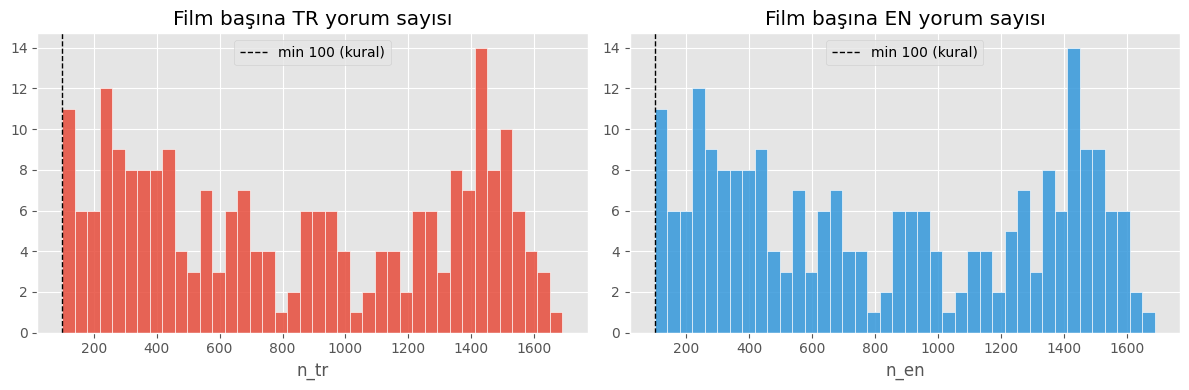

In [ ]:
top250 = pd.read_csv('raw/imdb_top250.csv')
id_col = 'imdb_id' if 'imdb_id' in top250.columns else 'tconst'
ids_top250 = set(top250[id_col].astype(str))
ids_corpus = set(df['imdb_id'].astype(str))

n_top = sum(1 for x in ids_corpus if x in ids_top250)
n_extra = len(ids_corpus) - n_top
print(f"Top 250 içindeki film sayısı (korpusta): {n_top} / {len(ids_top250)}")
print(f"Korpusta olup Top 250 listesinde olmayan imdb_id: {n_extra} (liste dışı ID varsa kontrol edin)")

per_film = df.groupby('imdb_id').size()
print(f"\nFilm başına toplam yorum — ortanca: {per_film.median():.0f}, ortalama: {per_film.mean():.1f}, min–max: {per_film.min()}–{per_film.max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ct_m['n_tr'], bins=40, color='#e74c3c', alpha=0.85, edgecolor='white')
axes[0].axvline(100, color='black', ls='--', lw=1, label='min 100 (kural)')
axes[0].set_title('Film başına TR yorum sayısı')
axes[0].set_xlabel('n_tr')
axes[0].legend()

axes[1].hist(ct_m['n_en'], bins=40, color='#3498db', alpha=0.85, edgecolor='white')
axes[1].axvline(100, color='black', ls='--', lw=1, label='min 100 (kural)')
axes[1].set_title('Film başına EN yorum sayısı')
axes[1].set_xlabel('n_en')
axes[1].legend()
plt.tight_layout()
plt.show()